In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shutil
import math 

from torchvision import datasets, transforms
# from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report
from math import pi as PI
from scipy.special import gamma, kv
from time import perf_counter
from reml import NadarayaWatsonClassifier

rng = np.random.default_rng() 

import matplotlib_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('retina')

plt.style.use('seaborn-v0_8-paper')
plt.rcParams.update(
    {
        'text.usetex': True
    }
)

In [2]:
# NOTE: AISTATS paper dimensions 
page_width_pt = 487.8225 
column_width_pt = 234.8775

def set_figure_size(width_pt, fraction=0.9, subplots=(1, 1), ratio=(5**0.5 - 1) / 2):
    fig_width_pt = width_pt * fraction
    inches_per_pt = 1 / 72.27

    fig_width_in = fig_width_pt * inches_per_pt
    fig_height_in = fig_width_in * ratio * (subplots[0] / subplots[1])

    return (fig_width_in, fig_height_in)

base_figure_size = set_figure_size(page_width_pt, 0.9, (1, 1))

In [32]:
num_train = 60000
num_test = 10 # minimum 10
# bandwidth = 7.47
bandwidth = 75.

rbf_kernel_hyperparameters = {'s': 1.1}
# matern_kernel_hps = {'s': 100.0, 'v': 3/2, 'l': np.sqrt(2)}
triweight_kernel_hyperparameters = {'s': 35/32}
boxcar_kernel_hyperparameters = {'s': 1.}

In [33]:
# Delete and redownload the MNIST dataset
# shutil.rmtree('./data', ignore_errors=True)
train_set = datasets.MNIST('./data', train=True, download=True)
test_set = datasets.MNIST('./data', train=False, download=True)

def load_train_set(n_train):
    num_train = n_train

    # Process training data
    train_set_array = train_set.data.numpy()
    x_train = train_set_array.reshape(train_set_array.shape[0], -1)[:num_train]
    x_train = x_train / 255.0  # Normalize to [0, 1]

    # Process training labels
    y_train = train_set.targets.numpy()[:num_train]

    # Create one-hot encoded labels for multi-class classification
    y_train_one_hot = np.zeros((num_train, 10))
    for i in range(num_train):
        y_train_one_hot[i, y_train[i]] = 1

    res = {'x_train': x_train, 'y_train': y_train, 'y_train_one_hot': y_train_one_hot}
    return res

def load_test_set(n_test):
    # Process test data - just take a few examples for demonstration
    test_set_array = test_set.data.numpy()
    y_test_all = test_set.targets.numpy()
    test_indices = []

    # First, ensure we have at least one of each digit (0-9)
    for digit in range(10):
        digit_indices = np.where(y_test_all == digit)[0]
        if len(digit_indices) > 0:
            # Select one random sample of this digit
            selected_idx = rng.choice(digit_indices, 1)[0]
            test_indices.append(selected_idx)

    # If we need additional samples to reach num_test
    remaining = n_test - len(test_indices)
    if remaining > 0:
        remaining_indices = np.setdiff1d(np.arange(len(y_test_all)), test_indices)
        additional_indices = rng.choice(remaining_indices, remaining, replace=False)
        test_indices.extend(additional_indices)

    test_indices = np.array(test_indices[:n_test])
    x_test = test_set_array[test_indices].reshape(n_test, -1)
    x_test = x_test / 255.0
    y_test = y_test_all[test_indices]

    res = {'x_test': x_test, 'y_test': y_test}
    return res



In [34]:
def create_circular_mask(h, w, center=None, radius=None):
    if center is None:
        center = (int(w/2) - 0.5, int(h/2) - 0.5)
    if radius is None:
        radius = min(center[0], center[1], w-center[0], h-center[1])
    Y, X = np.ogrid[:h, :w]
    dist_from_center = np.sqrt((X - center[0])**2 + (Y - center[1])**2)
    mask = dist_from_center <= radius
    return mask

# Precompute the mask for MNIST images (28x28, radius=12)
_circular_mask = create_circular_mask(28, 28, radius=12)

def load_train_set(n_train):
    num_train = n_train
    train_set_array = train_set.data.numpy()
    # Apply mask to each image, keep only pixels inside the circle
    x_train = train_set_array[:num_train]
    x_train = np.array([img[_circular_mask] for img in x_train])
    x_train = x_train / 255.0  # Normalize to [0, 1]
    y_train = train_set.targets.numpy()[:num_train]
    y_train_one_hot = np.zeros((num_train, 10))
    for i in range(num_train):
        y_train_one_hot[i, y_train[i]] = 1
    res = {'x_train': x_train, 'y_train': y_train, 'y_train_one_hot': y_train_one_hot}
    return res

def load_test_set(n_test):
    test_set_array = test_set.data.numpy()
    y_test_all = test_set.targets.numpy()
    test_indices = []
    for digit in range(10):
        digit_indices = np.where(y_test_all == digit)[0]
        if len(digit_indices) > 0:
            selected_idx = rng.choice(digit_indices, 1)[0]
            test_indices.append(selected_idx)
    remaining = n_test - len(test_indices)
    if remaining > 0:
        remaining_indices = np.setdiff1d(np.arange(len(y_test_all)), test_indices)
        additional_indices = rng.choice(remaining_indices, remaining, replace=False)
        test_indices.extend(additional_indices)
    test_indices = np.array(test_indices[:n_test])
    x_test = test_set_array[test_indices]
    x_test = np.array([img[_circular_mask] for img in x_test])
    x_test = x_test / 255.0
    y_test = y_test_all[test_indices]
    res = {'x_test': x_test, 'y_test': y_test}
    return res

In [35]:
"""
KERNEL FUNCTIONS
Here's where all the kernel functions are defined. If you want a new one, add them here. 
"""
def K_rbf(x, s):
    squared_exponential = s ** 2 * np.exp(-(x**2/2))    
    return 1e-8 if x > 1. else min(squared_exponential, 1.)

def K_boxcar(x, s=1.):
    return min(1., s) if x <= 1. else 1e-8

def K_linear(x, s : float = 1.):
    linear = s if x == 0. else s * x 
    return 1e-8 if x > 1. else linear

def K_matern(x, s, v, l):
    if np.isscalar(x) and x == 0:
        x = 1e-8
    elif isinstance(x, np.ndarray):
        x = x.copy()
        x[x==0] = 1e-8
    
    part1 = 2 ** (1 - v) / gamma(v)
    part2 = (np.sqrt(2 * v) * np.abs(x) / l) ** v
    part3 = kv(v, np.sqrt(2 * v) * np.abs(x) / l)
    
    return s**2 * part1 * part2 * part3

def K_epanechnikov(x, s: float = 1.):
    x = np.asarray(x)
    epanechnikov = np.where(x > 1., 1e-8, s * (1 - np.power(x, 2)))
    return epanechnikov

def K_quartic(x, s: float=15/16):
    quartic = s * (1 - x**2)**2
    return 1e-8 if x > 1. else quartic

def K_triweight(x, s:float=35/32):
    triweight = s * (1 - x**2)**3
    return 1e-8 if x > 1. else triweight

def K_cosine(x):
    cosine = PI/4 * np.cos((PI/2) * x)
    return 1e-8 if x > 1. else cosine

def K_tricube(x):
    tricube = (1 - abs(x)**3)**3
    return 1e-8 if x > 1. else tricube

# combination_kernel_1 = lambda x: K_rbf(x, 1e4) * K_boxcar(0.24*x)
# combination_kernel_2 = lambda x: K_rbf(x, 1e2) + K_matern(x, 1e2, 3/2, np.sqrt(2))

In [36]:
dataset = load_train_set(num_train)
validation = load_test_set(num_test)
x_train, y_train, y_train_one_hot = dataset.values()
x_test, y_test = validation.values()

In [37]:
x_test.shape

(10, 448)

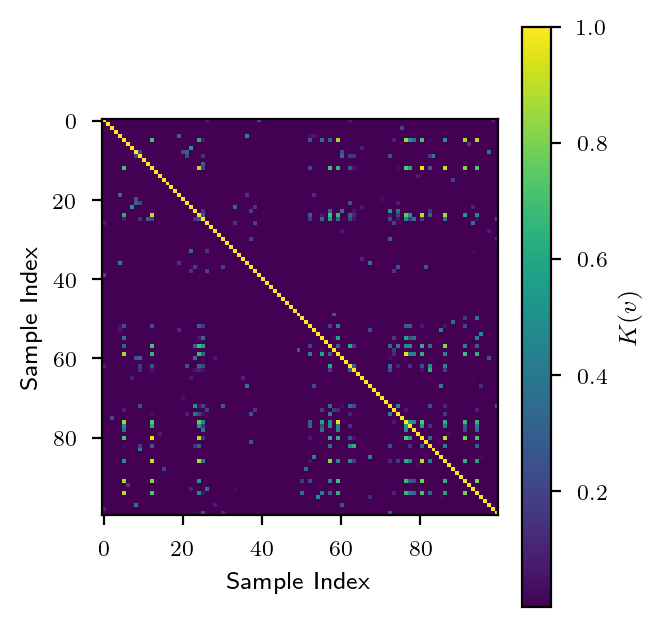

Kernel matrix shape: (100, 100)
Min kernel value: 0.000000
Max kernel value: 1.000000


In [38]:
"""
KERNEL MATRIX VISUALISATION
Pick a random 100 samples from the training set and compute the kernel matrix for each of those points
"""

n_random_samples = 100
random_indices = rng.choice(x_train.shape[0], n_random_samples, replace=False)
x_sample = x_train[random_indices]

# Compute pairwise distances
distances = np.zeros((n_random_samples, n_random_samples))
for i in range(n_random_samples):
    for j in range(n_random_samples):
        distances[i, j] = np.linalg.norm(x_sample[i] - x_sample[j], ord=1)

normalized_distances = distances / bandwidth

kernel_matrix = np.zeros((n_random_samples, n_random_samples))
for i in range(n_random_samples):
    for j in range(n_random_samples):
        # kernel_matrix[i, j] = K_rbf(normalized_distances[i, j], rbf_kernel_hyperparameters['s'])
        kernel_matrix[i, j] = K_epanechnikov(normalized_distances[i, j])

plt.figure(figsize=set_figure_size(page_width_pt, fraction=0.5, ratio=1.))
plt.imshow(kernel_matrix, cmap='viridis', interpolation='nearest')
plt.colorbar(label='$K(v)$')
# plt.title(f'RBF Kernel Matrix for {n_random_samples} Random Training Samples\n(bandwidth = {bandwidth})')
plt.xlabel('Sample Index')
plt.ylabel('Sample Index')
plt.tight_layout()
# plt.savefig('results/mnist/kernel_matrix.pdf')
plt.show()

print(f"Kernel matrix shape: {kernel_matrix.shape}")
print(f"Min kernel value: {kernel_matrix.min():.6f}")
print(f"Max kernel value: {kernel_matrix.max():.6f}")


In [39]:
predictions = []
probabilities = []
certainties = []

# nwc = NadarayaWatsonClassifier(bandwidth, 0.02, ck=1e4, kernel=K_rbf, kernel_kwargs=rbf_kernel_hyperparameters)
nwc = NadarayaWatsonClassifier(
    bandwidth=bandwidth, 
    lipschitz_constant=0.03, 
    ck=1.,
    kernel=K_epanechnikov
    # kernel_kwargs=rbf_kernel_hyperparameters
)

for i in range(num_test):
    probs, bounds = nwc.predict(x_test[i], x_train, y_train_one_hot)
    predicted_class = np.argmax(probs)
    predictions.append(predicted_class)
    probabilities.append(probs)
    certainties.append(bounds)
    # print(f"Test sample {i}: True label = {y_test[i]}, Predicted = {predicted_class}")
    # print(f"Maximum probability: {max(probs)}")

print(f"Average bound over {num_test} samples: {np.mean(certainties)}")

Average bound over 10 samples: 2.256005169871458


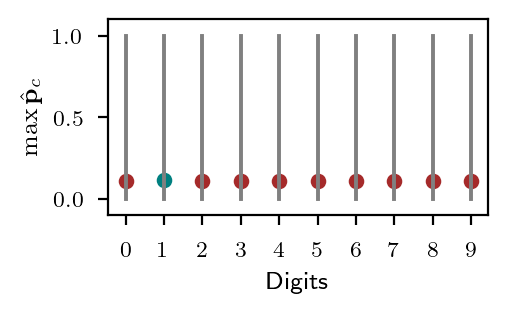

In [40]:
# Visualize maximum probabilities for each digit index with color coding
plt.figure(figsize=set_figure_size(page_width_pt, 0.4))
digit_indices = range(min(10, num_test))
max_probabilities = [max(prob) for prob in probabilities]

# Plot maximum probabilities with confidence intervals
for idx, (prob, bound) in enumerate(zip(max_probabilities, certainties)):
    color = 'teal' if predictions[idx] == y_test[idx] else 'brown'
    plt.plot(idx, prob, 'o', color=color)
    plt.plot([idx, idx], [max(0, prob-bound), min(1, prob+bound)], color='gray')

plt.ylim([-0.1, 1.1])
plt.xticks(digit_indices)
plt.ylabel(r'$\max \hat{\mathbf p}_c$')
plt.xlabel('Digits')
plt.tight_layout()
# plt.grid()
# plt.savefig('results/mnist/predictions.pgf')

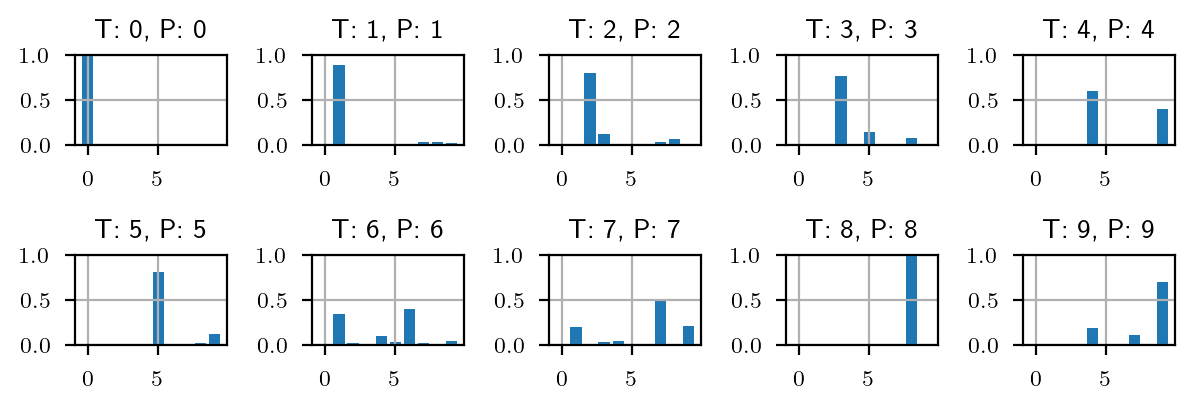

In [13]:
# visualise all the results
# Visualize all test results
plt.figure(figsize=set_figure_size(page_width_pt))

# Calculate number of rows needed
n_samples = min(10, num_test)  # Show up to 10 test samples
n_cols = 5  # 5 images per row

for i in range(n_samples):
    plt.subplot(4, n_cols, i + n_cols + 1)
    plt.bar(range(10), probabilities[i])
    plt.title(f"T: {y_test[i]}, P: {predictions[i]}")
    plt.grid()
    plt.ylim(0., 1.) 
    
plt.tight_layout()
#plt.show()

# plt.savefig('results/mnist/number_probs.pgf')
# plt.savefig('results/mnist/number_probs.pdf')

## Varying the Number of Training Points — effect on accuracy, runtime, and bounds

Here, we vary the number of training points from MNIST and then see the effect of the NW Classifier.  

In [14]:
num_trains = [1000, 2000, 5000, 10000, 20000, 30000, 60000]
num_test_accscore = 200
num_test = 10 

In [15]:
ACCURACIES = []
RUNTIMES = []
BOUNDS = []

noise_term = []
alpha_logs, kappa_logs = [], []

In [16]:
datasets = []
validationsets = []

for nt in num_trains:
    datasets.append(load_train_set(nt))
    validationsets.append(load_test_set(num_test_accscore))

for dataset in datasets:
    predictions = []
    probabilities = []
    certainties = []

    x_train, y_train, y_train_one_hot = dataset.values()
    x_test, y_test = validationsets[0].values()

    flag1 = perf_counter()
    for i in range(num_test_accscore):
        probs, bounds = nwc.predict(x_test[i], x_train, y_train_one_hot)
        predicted_class = np.argmax(probs)
        predictions.append(predicted_class)
        probabilities.append(probs)
        if i < 10:
            certainties.append(bounds)
            logs = nwc.logs()
            alpha, kappa = logs.values()
            foo = (2 * 0.25 * alpha)/kappa
            
            # logging
            alpha_logs.append(alpha)
            kappa_logs.append(kappa)
            noise_term.append(foo)
        else:
            pass 

    flag2 = perf_counter()

    
    correct_predictions = sum(predictions[i] == y_test[i] for i in range(len(predictions)))
    accuracy = correct_predictions / len(predictions) * 100
    ACCURACIES.append(accuracy)
    RUNTIMES.append(flag2 - flag1)
    BOUNDS.append(certainties)
    # print(f"Accuracy: {accuracy:.2f}% ({correct_predictions} out of {len(predictions)} correct)")

BOUNDS = np.array(BOUNDS)

noise_term = np.array(noise_term).reshape((len(num_trains), -1))
alpha_logs = np.array(alpha_logs).reshape((len(num_trains), -1))
kappa_logs = np.array(kappa_logs).reshape((len(num_trains), -1))

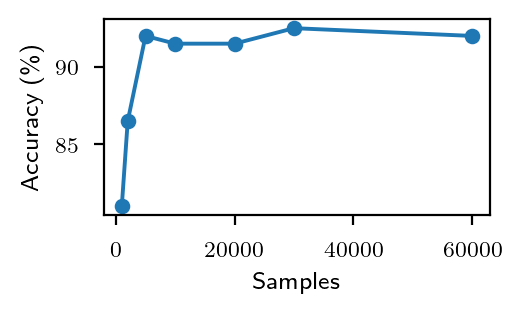

In [17]:
plt.figure(figsize=set_figure_size(page_width_pt, 0.4))

# plt.subplot(121)
plt.plot(num_trains, ACCURACIES, marker='o')
# for x, y in zip(num_trains, ACCURACIES):
#     plt.annotate(str(x/1000), (x, y), fontsize=7, xytext=(5, 5), textcoords='offset points')
# plt.xlabel('Samples (log-scale)')
plt.ylabel('Accuracy (\%)')
# plt.title('No. of training samples (in thousands, annotated)')

# plt.subplot(122)
# plt.plot(num_trains, RUNTIMES, marker='o')
# plt.yscale('log')
plt.xlabel('Samples')
# plt.ylabel('Runtime (s) log-scale')
# plt.title('Runtime for 200 samples')

# plt.show()
plt.tight_layout()
# plt.savefig('results/mnist/accuracy.pgf')

#plt.show()


# plt.subplot(3, 2, (3, 4))
# for i in range(10):
#     plt.plot(num_trains, BOUNDS[:, i], label=f'{i}')
# plt.yscale('log')
# plt.xlabel('No. of training samples')
# plt.ylabel('Bounds for each digit, 1-9')
# plt.legend()

# plt.subplot(3, 2, (5, 6))
# for i in range(10):
#     plt.plot(num_trains, noise_term[:, i], label=f'{i}')
# plt.yscale('log')
# plt.xlabel('No. of training samples')
# plt.ylabel(r'$2 \sigma \alpha / \kappa_n$')
# plt.legend()

# plt.tight_layout()
# #plt.show()

# plt.savefig('fig3.pdf')

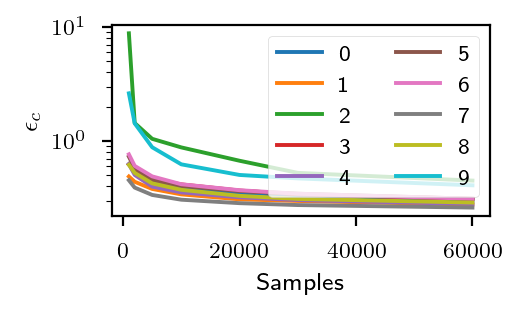

In [18]:
plt.figure(figsize=set_figure_size(page_width_pt, fraction=0.4))
for i in range(10):
    plt.plot(num_trains, BOUNDS[:, i], label=f'{i}')
plt.yscale('log')
plt.xlabel('Samples')
plt.ylabel(r'$\epsilon_c$')
plt.legend(ncol=2)

# plt.subplot(3, 2, (5, 6))
# for i in range(10):
#     plt.plot(num_trains, noise_term[:, i], label=f'{i}')
# plt.yscale('log')
# plt.xlabel('No. of training samples')
# plt.ylabel(r'$2 \sigma \alpha / \kappa_n$')
# plt.legend()

plt.tight_layout()
# plt.savefig('results/mnist/bounds_tightening.pgf')